# Hardware Verification

This notebook is a standalone bridge between a previously trained hybrid quantum-classical model and Qiskit-based circuit execution.

It does **not** depend on the training session being live. Instead it reads pre-saved quantum artifacts produced by `qnn_speech_recognition.ipynb` via `src.quantum_weights.export_quantum_artifacts()`.

## Execution paths

| Path | Backend | Purpose |
|---|---|---|
| **Simulator** | `AerSimulator` (local) | Validate the reconstructed Qiskit circuit before spending quantum credits |
| **Real hardware** | IBM Quantum (Job mode) | Run one or a few samples on a real QPU |

> **Always run the simulator path first.**  
> Validate circuit outputs are sensible before switching to hardware.

## Artifact files expected

```
<ARTIFACTS_DIR>/
  quantum_metadata.json   ← n_qubits, q_depth, classifier metadata
  quantum_weights.npz     ← trained gate parameter arrays
  quantum_inputs.npy      ← real quantum-layer inputs from validation data
```

These are written by calling `export_quantum_artifacts(model, sample_input, save_dir=...)` in the training notebook.

## 1. Install Dependencies
Run this cell on first launch in Colab. Skip if dependencies are already present.

In [59]:
# Install Qiskit and Aer simulator (Colab)
import subprocess, sys

packages = [
    "qiskit[all]~=2.3.0",
    "qiskit-aer~=0.17.0",
    "qiskit-ibm-runtime~=0.43.1",
    "matplotlib",
    "pylatexenc",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg])

print("Dependencies ready.")

Dependencies ready.


In [60]:
# Colab setup: mount Drive, clone repo, checkout fine-tunning branch
import os, sys, subprocess
from pathlib import Path

REPO_URL = 'https://github.com/lburdman/qnn-transfer-learning.git'
REPO_PATH = Path('/content/qnn-transfer-learning')
BRANCH = 'feat/full-inference-verification'

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    if not REPO_PATH.exists():
        subprocess.run(['git', 'clone', REPO_URL, str(REPO_PATH)], check=True)
    os.chdir(REPO_PATH)
    subprocess.run(['git', 'fetch'], check=True)
    subprocess.run(['git', 'checkout', BRANCH], check=True)
    subprocess.run(['git', 'pull', 'origin', BRANCH], check=True)
else:
    os.chdir(Path('.'))

sys.path.append(str(Path.cwd() / 'src'))
print('Working dir:', Path.cwd())
print('Python path updated with src/')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/qnn-transfer-learning
Python path updated with src/


## 2. Configuration

Edit the variables in this cell to match your environment.  
Everything downstream reads from these variables; no other cell needs manual editing.

In [ ]:
# ============================================================
# CONFIGURATION — edit these before running any other cell
# ============================================================

# Path to the verification bundle exported by qnn_speech_recognition.ipynb cell 23
ARTIFACTS_DIR = "/content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/hw_verification/quantum_artifacts"

# Execution mode:
#   'simulator' -> local AerSimulator (always run this first — free, no IBM account needed)
#   'hardware'  -> real IBM Quantum backend via Runtime Job mode
MODE = "simulator"

# --- Sample counts ---
# Both are automatically clamped to the size of the exported verification bundle on load.
# Simulator: safe to set high (local run, no cost).
# Hardware:  keep low to manage Open Plan credit consumption.
N_SAMPLES_SIM = 100    # simulator evaluates up to this many exported samples
N_SAMPLES_HW  = 100    # hardware evaluates up to this many (same subset prefix)

# Measurement shots per circuit
SHOTS = 1024

# --- IBM Quantum Runtime credentials (hardware mode only) ---
# Preferred: set IBM_QUANTUM_TOKEN and IBM_CRN in Colab Secrets.
IBM_TOKEN    = ""            # leave empty to load from Colab Secrets / env
IBM_CHANNEL  = "ibm_quantum_platform"
IBM_INSTANCE = ""            # leave empty to load from IBM_CRN Colab Secret

# Backend selection policy (hardware mode only):
#   'auto'   -> least-busy real backend with >= MIN_NUM_QUBITS qubits
#   'manual' -> use PREFERRED_BACKEND_NAME
BACKEND_SELECTION = "auto"
PREFERRED_BACKEND_NAME = "ibm_kyoto"
MIN_NUM_QUBITS = 2

print(f"MODE          = {MODE}")
print(f"N_SAMPLES_SIM = {N_SAMPLES_SIM}  (clipped to bundle size on load)")
print(f"N_SAMPLES_HW  = {N_SAMPLES_HW}   (clipped to N_SAMPLES_SIM on load)")
print(f"SHOTS         = {SHOTS}")
if MODE == "hardware":
    print(f"IBM_CHANNEL       = {IBM_CHANNEL}")
    print(f"BACKEND_SELECTION = {BACKEND_SELECTION}")
else:
    print("BACKEND       = local AerSimulator")


In [62]:
# --- Optional IBM Quantum Runtime service setup ---
# This is only needed when MODE == "hardware".

service = None

if MODE == "hardware":
    try:
        from google.colab import userdata
    except Exception:
        userdata = None

    from qiskit_ibm_runtime import QiskitRuntimeService

    token = IBM_TOKEN
    instance = IBM_INSTANCE

    if not token and userdata is not None:
        try:
            token = userdata.get("IBM_QUANTUM_TOKEN")
            if token:
                print("Loaded IBM token from Colab Secrets.")
        except Exception:
            pass

    if not instance and userdata is not None:
        try:
            instance = userdata.get("IBM_CRN")
            if instance:
                print("Loaded IBM instance CRN from Colab Secrets.")
        except Exception:
            pass

    if not token:
        raise ValueError(
            "Missing IBM Quantum token. Set IBM_QUANTUM_TOKEN in Colab Secrets or IBM_TOKEN manually."
        )

    service_kwargs = {
        "channel": IBM_CHANNEL,
        "token": token,
    }

    # On the current platform, instance is optional, but use it if available.
    if instance:
        service_kwargs["instance"] = instance

    service = QiskitRuntimeService(**service_kwargs)

    print("Qiskit Runtime service initialized successfully.")
    if instance:
        print(f"Using instance/CRN: {instance}")
    else:
        print("No instance specified; service will resolve backends across available instances.")
else:
    print("MODE='simulator' — IBM Runtime service initialization skipped.")

Loaded IBM token from Colab Secrets.


qiskit_runtime_service._discover_account:WARNING:2026-03-18 05:25:10,562: Loading account with the given token. A saved account will not be used.


Loaded IBM instance CRN from Colab Secrets.
Qiskit Runtime service initialized successfully.
Using instance/CRN: crn:v1:bluemix:public:quantum-computing:us-east:a/47775e7c2ef846ab8bb3c813fa79eee9:907ca93f-8c4a-4c18-a619-84a611f84f8f::


## 3. Load and Validate Quantum Artifacts

This section loads the three artifact files and validates them before any circuit is built.

- `quantum_metadata.json` — contains `n_qubits`, `q_depth`, and summary statistics.
- `quantum_weights.npz` — the trained gate parameters with shape `(q_depth, n_qubits)`.
- `quantum_inputs.npy` — real inputs pre-captured at the quantum layer boundary from validation data,
  shape `(n_validation_samples, n_qubits)`.

In [ ]:
import os, json
import numpy as np
from pathlib import Path

artifacts_dir = Path(ARTIFACTS_DIR)

required_files = {
    "metadata": artifacts_dir / "quantum_metadata.json",
    "weights":  artifacts_dir / "quantum_weights.npz",
    "inputs":   artifacts_dir / "quantum_inputs.npy",
}
missing = [name for name, path in required_files.items() if not path.exists()]
if missing:
    raise FileNotFoundError(
        f"Missing required artifact files: {missing}\n"
        f"Expected in: {artifacts_dir}\n"
        "Run qnn_speech_recognition.ipynb cell 23 with USE_QUANTUM=True."
    )
print("✓ Required artifact files found.")

# --- Quantum metadata ---
with open(required_files["metadata"]) as f:
    metadata = json.load(f)

N_QUBITS = metadata["n_qubits"]
Q_DEPTH  = metadata["q_depth"]
print(f"\n--- Quantum Metadata ---")
print(f"  n_qubits : {N_QUBITS}")
print(f"  q_depth  : {Q_DEPTH}")

# --- Gate weights ---
weights_npz = np.load(required_files["weights"])
WEIGHT_KEYS = list(weights_npz.files)
WEIGHTS_KEY = "weights" if "weights" in WEIGHT_KEYS else WEIGHT_KEYS[0]
GATE_WEIGHTS = weights_npz[WEIGHTS_KEY]
if GATE_WEIGHTS.shape != (Q_DEPTH, N_QUBITS):
    print(f"  WARNING: reshaping gate weights from {GATE_WEIGHTS.shape} to ({Q_DEPTH}, {N_QUBITS})")
    GATE_WEIGHTS = GATE_WEIGHTS.reshape(Q_DEPTH, N_QUBITS)
print(f"  gate_weights shape : {GATE_WEIGHTS.shape}")

# --- Quantum inputs ---
QUANTUM_INPUTS = np.load(required_files["inputs"])
print(f"  quantum_inputs shape: {QUANTUM_INPUTS.shape}  (samples × n_qubits)")
if QUANTUM_INPUTS.shape[1] != N_QUBITS:
    raise ValueError(f"quantum_inputs has {QUANTUM_INPUTS.shape[1]} features != n_qubits={N_QUBITS}")

# --- Optional artifacts for full inference ---
optional = {
    "classifier_weight": artifacts_dir / "classifier_weight.npy",
    "classifier_bias":   artifacts_dir / "classifier_bias.npy",
    "true_labels":       artifacts_dir / "true_labels.npy",
    "class_names":       artifacts_dir / "class_names.json",
    "reference_logits":  artifacts_dir / "reference_logits.npy",
    "reference_preds":   artifacts_dir / "reference_preds.npy",
    "sample_ids":        artifacts_dir / "sample_ids.json",
    "manifest":          artifacts_dir / "bundle_manifest.json",
}

CLASSIFIER_WEIGHT = None
CLASSIFIER_BIAS   = None
TRUE_LABELS       = None
CLASS_NAMES       = None
REFERENCE_LOGITS  = None
REFERENCE_PREDS   = None
SAMPLE_IDS        = None
BUNDLE_MANIFEST   = None

for name, path in optional.items():
    if path.exists():
        if name in ("class_names", "sample_ids", "manifest"):
            with open(path) as _f:
                val = json.load(_f)
            if name == "class_names":   CLASS_NAMES    = val
            elif name == "sample_ids":  SAMPLE_IDS     = val
            elif name == "manifest":    BUNDLE_MANIFEST = val
        else:
            arr = np.load(path)
            if   name == "classifier_weight": CLASSIFIER_WEIGHT = arr
            elif name == "classifier_bias":   CLASSIFIER_BIAS   = arr
            elif name == "true_labels":       TRUE_LABELS       = arr
            elif name == "reference_logits":  REFERENCE_LOGITS  = arr
            elif name == "reference_preds":   REFERENCE_PREDS   = arr
    else:
        print(f"  Optional not found (skipped): {name}")

# --- Print loaded state ---
if BUNDLE_MANIFEST:
    print(f"\n--- Bundle Manifest ---")
    for k, v in BUNDLE_MANIFEST.items():
        print(f"  {k}: {v}")

if CLASSIFIER_WEIGHT is not None:
    print(f"\n--- Final Classifier ---")
    print(f"  weight: {CLASSIFIER_WEIGHT.shape}  (n_classes x n_qubits)")
    print(f"  bias  : {CLASSIFIER_BIAS.shape}")

if CLASS_NAMES:
    print(f"  classes: {CLASS_NAMES}")

if TRUE_LABELS is not None:
    label_strs = [CLASS_NAMES[int(l)] for l in TRUE_LABELS] if CLASS_NAMES else TRUE_LABELS.tolist()
    print(f"  true_labels: {label_strs}")

# --- Resolve and clamp sample counts ---
_bundle_size = len(QUANTUM_INPUTS)

N_SAMPLES_SIM = min(N_SAMPLES_SIM, _bundle_size)
N_SAMPLES_HW  = min(N_SAMPLES_HW,  N_SAMPLES_SIM)

# --- Print loaded optional artifacts ---
if BUNDLE_MANIFEST:
    print(f"\n--- Bundle Manifest ---")
    for k, v in BUNDLE_MANIFEST.items():
        print(f"  {k}: {v}")

if CLASSIFIER_WEIGHT is not None and CLASSIFIER_BIAS is not None:
    print(f"\n--- Final Classifier ---")
    print(f"  weight : {CLASSIFIER_WEIGHT.shape}  (n_classes x n_qubits)")
    print(f"  bias   : {CLASSIFIER_BIAS.shape}")

if CLASS_NAMES:
    print(f"  classes: {CLASS_NAMES}")

if TRUE_LABELS is not None:
    label_strs = [CLASS_NAMES[int(l)] for l in TRUE_LABELS] if CLASS_NAMES else TRUE_LABELS.tolist()
    print(f"  true_labels (bundle): {label_strs}")

if REFERENCE_PREDS is not None and CLASS_NAMES and TRUE_LABELS is not None:
    ref_strs = [CLASS_NAMES[int(p)] for p in REFERENCE_PREDS]
    ref_acc  = (REFERENCE_PREDS == TRUE_LABELS).mean() * 100
    print(f"  PL reference preds  : {ref_strs}")
    print(f"  PL reference accuracy (full bundle): {ref_acc:.1f}%")

# CAN_DO_FULL_INFERENCE is True only when classifier weights AND bias are loaded.
# Used by cells 24 (simulator) and 37 (hardware) to decide whether to apply
# the trained classifier on top of raw quantum outputs.
CAN_DO_FULL_INFERENCE = (CLASSIFIER_WEIGHT is not None and CLASSIFIER_BIAS is not None)

print(f"\n--- Sample Counts ---")
print(f"  Bundle size                 : {_bundle_size}")
print(f"  Simulator will evaluate     : {N_SAMPLES_SIM} sample(s)")
print(f"  Hardware  will evaluate     : {N_SAMPLES_HW} sample(s)  (first {N_SAMPLES_HW} of same subset)")
print(f"  CAN_DO_FULL_INFERENCE       : {CAN_DO_FULL_INFERENCE}")
if not CAN_DO_FULL_INFERENCE:
    print("  WARNING: classifier_weight.npy / classifier_bias.npy not found.")
    print("  Re-run qnn_speech_recognition.ipynb cell 23 to generate them.")


## 4. Reference: PennyLane Quantum Head Architecture

The trained model's quantum head is built in `src/model_builder.py` using PennyLane:

```python
@qml.qnode(dev)
def circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))      # encode features as rotation angles
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))  # parameterized entangling layers
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
```

- `AngleEmbedding` maps each of the `n_qubits` input features to an `RX` rotation angle.
- `BasicEntanglerLayers` applies `q_depth` layers of `RX(θ)` rotations + nearest-neighbour `CNOT` entanglement.
- Expectation values of **PauliZ** on each qubit form the output vector, which feeds a final `nn.Linear → n_classes`.

The Qiskit circuit below faithfully mirrors this structure.

In [64]:
# ── HARDWARE ONLY ──
if MODE != "hardware":
    print("MODE is 'simulator' — skipping backend selection.")
else:
    if service is None:
        raise RuntimeError("IBM Runtime service is not initialized.")

    if BACKEND_SELECTION == "manual":
        hw_backend = service.backend(PREFERRED_BACKEND_NAME)
    else:
        candidates = service.backends(
            simulator=False,
            operational=True,
            min_num_qubits=max(MIN_NUM_QUBITS, N_QUBITS),
        )

        if not candidates:
            raise RuntimeError("No operational non-simulator backends available.")

        # Conservative least-busy selection
        hw_backend = min(
            candidates,
            key=lambda b: getattr(b.status(), "pending_jobs", float("inf"))
        )

    n_hw_qubits = hw_backend.num_qubits
    print(f"Selected backend : {hw_backend.name}")
    print(f"Pending jobs     : {hw_backend.status().pending_jobs}")
    print(f"Qubits available : {n_hw_qubits}")
    print(f"Circuit requires : {N_QUBITS}")

    if n_hw_qubits < N_QUBITS:
        raise ValueError(
            f"Backend '{hw_backend.name}' has only {n_hw_qubits} qubits "
            f"but circuit needs {N_QUBITS}."
        )

    print("✓ Backend has sufficient qubits.")

Selected backend : ibm_fez
Pending jobs     : 0
Qubits available : 156
Circuit requires : 2
✓ Backend has sufficient qubits.


## 5. Qiskit Circuit Reconstruction

We build a **parameterized** Qiskit `QuantumCircuit` that mirrors the PennyLane head:

1. `AngleEmbedding` → `RX(θ_i)` gates on each qubit
2. `BasicEntanglerLayers` (one layer) → `RX(w_layer_i)` + `CNOT` ring entanglement

The circuit uses Qiskit `Parameter` objects so we can bind different input samples without rebuilding the circuit.

In [65]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

def build_qiskit_circuit(n_qubits: int, q_depth: int) -> QuantumCircuit:
    """
    Build a parameterized Qiskit circuit that mirrors the PennyLane quantum head:
      - AngleEmbedding  → RX gates with input parameters
      - BasicEntanglerLayers → q_depth layers of RX(weight) + CNOT ring

    Classical shadow measurement is omitted here; we measure all qubits in Z-basis
    (equivalent to computing <Z> expectation via bitstring probabilities).

    Args:
        n_qubits: Number of qubits.
        q_depth:  Number of BasicEntanglerLayers repetitions.

    Returns:
        qc         : ParameterizedQuantumCircuit
        input_params  : ParameterVector for AngleEmbedding
        weight_params : ParameterVector for gate weights (shape: q_depth × n_qubits)
    """
    input_params  = ParameterVector('x', length=n_qubits)
    weight_params = ParameterVector('w', length=q_depth * n_qubits)

    qc = QuantumCircuit(n_qubits, n_qubits)

    # --- AngleEmbedding ---
    for i in range(n_qubits):
        qc.rx(input_params[i], i)

    # --- BasicEntanglerLayers ---
    w_idx = 0
    for layer in range(q_depth):
        # RX rotations
        for i in range(n_qubits):
            qc.rx(weight_params[w_idx], i)
            w_idx += 1
        # Circular CNOT entanglement
        for i in range(n_qubits):
            qc.cx(i, (i + 1) % n_qubits)
        if layer < q_depth - 1:
            qc.barrier()

    # Measure all qubits in Z-basis
    qc.measure(range(n_qubits), range(n_qubits))

    return qc, input_params, weight_params


# Build the circuit
QC, INPUT_PARAMS, WEIGHT_PARAMS = build_qiskit_circuit(N_QUBITS, Q_DEPTH)

print(f"Reconstructed Qiskit circuit:")
print(f"  qubits         : {N_QUBITS}")
print(f"  depth param    : {Q_DEPTH}")
print(f"  input params   : {len(INPUT_PARAMS)}")
print(f"  weight params  : {len(WEIGHT_PARAMS)}  (expected {Q_DEPTH * N_QUBITS})")
print(f"  circuit depth  : {QC.depth()}")

Reconstructed Qiskit circuit:
  qubits         : 2
  depth param    : 3
  input params   : 2
  weight params  : 6  (expected 6)
  circuit depth  : 11


## 6. Circuit Visualization (Pre-Transpile)

Here we draw the reconstructed circuit in its parameterized, hardware-agnostic form.  
This is the logical circuit — gate structure mirrors the PennyLane model directly.

=== Parameterized circuit (pre-transpile, text view) ===
     ┌──────────┐┌──────────┐     ┌───┐ ░ ┌──────────┐     ┌───┐ ░ ┌──────────┐     ┌───┐┌─┐   
q_0: ┤ Rx(x[0]) ├┤ Rx(w[0]) ├──■──┤ X ├─░─┤ Rx(w[2]) ├──■──┤ X ├─░─┤ Rx(w[4]) ├──■──┤ X ├┤M├───
     ├──────────┤├──────────┤┌─┴─┐└─┬─┘ ░ ├──────────┤┌─┴─┐└─┬─┘ ░ ├──────────┤┌─┴─┐└─┬─┘└╥┘┌─┐
q_1: ┤ Rx(x[1]) ├┤ Rx(w[1]) ├┤ X ├──■───░─┤ Rx(w[3]) ├┤ X ├──■───░─┤ Rx(w[5]) ├┤ X ├──■───╫─┤M├
     └──────────┘└──────────┘└───┘      ░ └──────────┘└───┘      ░ └──────────┘└───┘      ║ └╥┘
c: 2/═════════════════════════════════════════════════════════════════════════════════════╩══╩═
                                                                                          0  1 


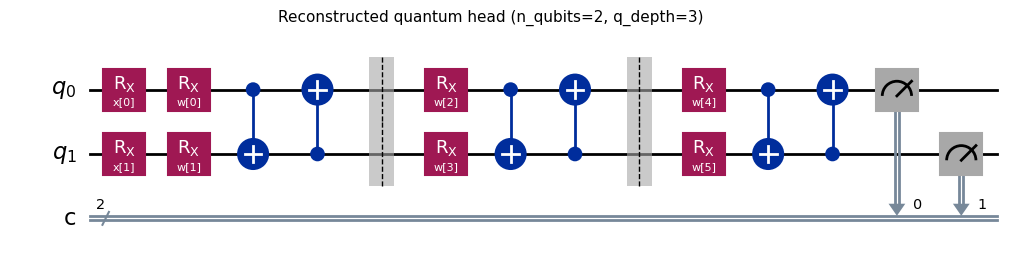

In [66]:
from IPython.display import display
import matplotlib.pyplot as plt

print("=== Parameterized circuit (pre-transpile, text view) ===")
print(QC.draw(output="text", fold=120))

try:
    fig = QC.draw(output="mpl", fold=120)
    fig.suptitle(
        f"Reconstructed quantum head (n_qubits={N_QUBITS}, q_depth={Q_DEPTH})",
        fontsize=11
    )
    display(fig)
    plt.close(fig)
except Exception as e:
    print(f"Matplotlib render skipped: {e}")

=== Transpiled circuit (text view) ===
global phase: 3π/2
         ┌─────────┐┌────┐┌──────────────┐┌────────┐┌──────────────┐   ┌────┐   ┌──────────┐   ┌─────────┐┌────┐»
q_0 -> 0 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π + x[0]) ├┤ Rz(-π) ├┤ Rz(π + w[0]) ├───┤ √X ├───┤ Rz(5π/2) ├─■─┤ Rz(π/2) ├┤ √X ├»
         ├─────────┤├────┤├──────────────┤├────────┤├──────────────┤┌──┴────┴──┐└──────────┘ │ ├─────────┤├────┤»
q_1 -> 1 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π + x[1]) ├┤ Rz(-π) ├┤ Rz(π + w[1]) ├┤ Rz(-π/2) ├─────────────■─┤ Rz(π/2) ├┤ √X ├»
         └─────────┘└────┘└──────────────┘└────────┘└──────────────┘└──────────┘               └─────────┘└────┘»
    c: 2/═══════════════════════════════════════════════════════════════════════════════════════════════════════»
                                                                                                                »
«         ┌─────────┐   ┌─────────┐┌────┐┌─────────┐ ░ ┌─────────┐┌────┐┌──────────────┐   ┌────┐   ┌──────────┐   »
«q_0 -> 0 ┤ Rz(π/2) ├─■─┤ R

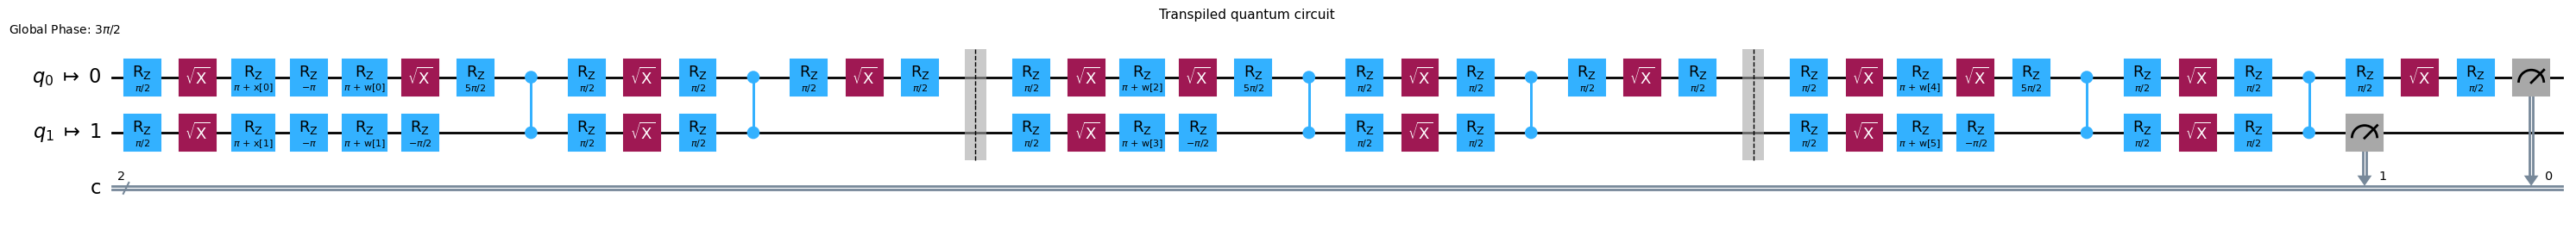

In [67]:
from qiskit import transpile
from IPython.display import display
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator

# Choose a backend object for visualization/transpile
if MODE == "simulator":
    viz_backend = AerSimulator()
else:
    # If hardware backend is not selected yet, defer this cell until after backend selection.
    if "hw_backend" not in globals() or hw_backend is None:
        raise RuntimeError(
            "Hardware backend not selected yet. Run the hardware backend selection cell first."
        )
    viz_backend = hw_backend

QC_T = transpile(QC, backend=viz_backend, optimization_level=1)

print("=== Transpiled circuit (text view) ===")
print(QC_T.draw(output="text", fold=120))

try:
    fig_t = QC_T.draw(output="mpl", fold=120)
    fig_t.suptitle("Transpiled quantum circuit", fontsize=11)
    display(fig_t)
    plt.close(fig_t)
except Exception as e:
    print(f"Matplotlib transpiled render skipped: {e}")

---
## 7. Simulator Path (AerSimulator)

Use this section to validate the reconstructed circuit locally before touching real hardware.  
The `AerSimulator` runs on your CPU/GPU — it is fast and free, with no IBM account required.

**Run this section first. Always.**

### 7a. Set up AerSimulator backend

In [68]:
# ── SIMULATOR ONLY ──
# This cell is irrelevant when MODE='hardware'. Safe to skip.

from qiskit_aer import AerSimulator

sim_backend = AerSimulator()
print(f"Simulator backend: {sim_backend.name}")
print(f"Basis gates: {sim_backend.configuration().basis_gates}")

Simulator backend: aer_simulator
Basis gates: ['ccx', 'ccz', 'cp', 'crx', 'cry', 'crz', 'cswap', 'csx', 'cu', 'cu1', 'cu2', 'cu3', 'cx', 'cy', 'cz', 'diagonal', 'ecr', 'h', 'id', 'mcp', 'mcphase', 'mcr', 'mcrx', 'mcry', 'mcrz', 'mcswap', 'mcsx', 'mcu', 'mcu1', 'mcu2', 'mcu3', 'mcx', 'mcx_gray', 'mcy', 'mcz', 'multiplexer', 'p', 'pauli', 'r', 'roerror', 'rx', 'rxx', 'ry', 'ryy', 'rz', 'rzx', 'rzz', 's', 'sdg', 'store', 'swap', 'sx', 'sxdg', 't', 'tdg', 'u', 'u1', 'u2', 'u3', 'unitary', 'x', 'y', 'z', 'break_loop', 'continue_loop', 'delay', 'for_loop', 'if_else', 'initialize', 'kraus', 'qerror_loc', 'quantum_channel', 'reset', 'roerror', 'save_amplitudes', 'save_amplitudes_sq', 'save_clifford', 'save_density_matrix', 'save_expval', 'save_expval_var', 'save_matrix_product_state', 'save_probabilities', 'save_probabilities_dict', 'save_stabilizer', 'save_state', 'save_statevector', 'save_statevector_dict', 'save_superop', 'save_unitary', 'set_density_matrix', 'set_matrix_product_state', 'se

### 7b. Bind quantum-input samples

We bind the trained weights (loaded from `quantum_weights.npz`) and the real validation-time inputs
(from `quantum_inputs.npy`) into the parameterized circuit.  
This produces a concrete, executable circuit per sample.

In [ ]:
# ── SIMULATOR ONLY ──
# This cell binds the full simulator subset (N_SAMPLES_SIM circuits).
# The hardware path will use only the first N_SAMPLES_HW of these same circuits.

def bind_sample(qc, input_params, weight_params, input_vec, weight_arr):
    """Bind one quantum-input vector + trained gate weights into the parameterized circuit."""
    flat_weights = weight_arr.flatten().tolist()
    param_bindings = {}
    for i, p in enumerate(input_params):
        param_bindings[p] = float(input_vec[i])
    for i, p in enumerate(weight_params):
        param_bindings[p] = float(flat_weights[i])
    return qc.assign_parameters(param_bindings)


# Bind all N_SAMPLES_SIM circuits (simulator uses all; hardware uses first N_SAMPLES_HW)
BOUND_CIRCUITS = []
for idx in range(N_SAMPLES_SIM):
    input_vec = QUANTUM_INPUTS[idx]
    bound_qc  = bind_sample(QC, INPUT_PARAMS, WEIGHT_PARAMS, input_vec, GATE_WEIGHTS)
    BOUND_CIRCUITS.append(bound_qc)
    print(f"  Bound circuit {idx}: {len(INPUT_PARAMS)} input + {len(WEIGHT_PARAMS)} weight params")

print(f"\n✓ {len(BOUND_CIRCUITS)} circuit(s) bound.")
print(f"  Simulator will run    : circuits 0–{N_SAMPLES_SIM - 1}")
print(f"  Hardware will run     : circuits 0–{N_SAMPLES_HW - 1}  (first {N_SAMPLES_HW} only)")


### 7c. Run on AerSimulator

In [ ]:
# ── SIMULATOR ONLY ──
# Run all N_SAMPLES_SIM bound circuits on the local AerSimulator.
from qiskit_aer import AerSimulator
from qiskit import transpile

sim_backend = AerSimulator()

print(f"Transpiling {len(BOUND_CIRCUITS)} circuit(s) for AerSimulator...")
transpiled_for_sim = transpile(BOUND_CIRCUITS, backend=sim_backend, optimization_level=1)
print("Transpilation done.")

print(f"Running {len(BOUND_CIRCUITS)} circuit(s) with {SHOTS} shots each...")
sim_job    = sim_backend.run(transpiled_for_sim, shots=SHOTS)
sim_result = sim_job.result()
print(f"\n✓ Simulator job complete.  ({N_SAMPLES_SIM} sample(s) evaluated)")


### 7d. Inspect simulator results

In [ ]:
# ── SIMULATOR ONLY ──
# Extract <Z> expectation values, apply the trained classifier, and report per-sample results.

def expectation_z_from_counts(counts: dict, n_qubits: int) -> list:
    """Compute <Z_i> = (N_0_i - N_1_i) / N_total for each qubit from bitstring counts."""
    total  = sum(counts.values())
    expvals = [0.0] * n_qubits
    for bitstring, count in counts.items():
        bits = bitstring.replace(" ", "")
        for i in range(n_qubits):
            bit_val = int(bits[-(i + 1)]) if (i + 1) <= len(bits) else 0
            expvals[i] += count * (1 - 2 * bit_val)
    return [v / total for v in expvals]


import numpy as np

def apply_classifier(expvals_list, classifier_weight, classifier_bias, class_names=None):
    """Apply saved nn.Linear (weight, bias) to a list of <Z> vectors. Returns list of result dicts."""
    results = []
    for idx, ev in enumerate(expvals_list):
        q_out    = np.array(ev, dtype=np.float32)
        logits   = classifier_weight @ q_out + classifier_bias
        pred_idx = int(np.argmax(logits))
        results.append({
            "sample_idx": idx,
            "quantum_out": ev,
            "logits": logits.tolist(),
            "pred_idx": pred_idx,
            "pred_name": class_names[pred_idx] if class_names else str(pred_idx),
        })
    return results


def report_results(results, true_labels=None, class_names=None, reference_preds=None, title=""):
    """Print per-sample inference table and accuracy summary."""
    if title:
        sep = "=" * 55
        print(f"\n{sep}\n {title}\n{sep}")
    correct = 0
    for r in results:
        idx       = r["sample_idx"]
        true_idx  = int(true_labels[idx])    if true_labels  is not None else None
        true_name = class_names[true_idx]    if (class_names and true_idx is not None) else str(true_idx)
        ref_idx   = int(reference_preds[idx]) if reference_preds is not None else None
        ref_name  = class_names[ref_idx]     if (class_names and ref_idx  is not None) else None
        match     = (r["pred_idx"] == true_idx) if true_idx is not None else None
        sym       = "\u2713" if match else "\u2717"
        if match: correct += 1
        logits_str = [f"{v:.3f}" for v in r["logits"]]
        zexp_str   = [f"{v:.3f}" for v in r["quantum_out"]]
        print(f"  Sample {idx:02d}: true={true_name:>6} | pred={r['pred_name']:>6} {sym} | "
              f"logits={logits_str} | <Z>={zexp_str}")
        if ref_name:
            print(f"           PL reference: {ref_name}")
    if true_labels is not None:
        n   = len(results)
        acc = correct / n * 100 if n > 0 else 0.0
        print(f"\n  Accuracy: {correct}/{n} = {acc:.1f}%")
        if reference_preds is not None:
            ref_ok = sum(
                int(reference_preds[r["sample_idx"]]) == int(true_labels[r["sample_idx"]])
                for r in results if r["sample_idx"] < len(reference_preds)
            )
            print(f"  PL reference accuracy (same subset): {ref_ok}/{n} = {ref_ok/n*100:.1f}%")


# Collect <Z> expectation vectors for all N_SAMPLES_SIM simulator runs
SIM_EXPVALS = []
for idx in range(N_SAMPLES_SIM):
    counts = sim_result.get_counts(idx)
    ev     = expectation_z_from_counts(counts, N_QUBITS)
    SIM_EXPVALS.append(ev)
    print(f"  Sample {idx}: top bitstrings={dict(sorted(counts.items(), key=lambda x: -x[1])[:4])}")
    print(f"           <Z>={[round(v,4) for v in ev]}")

# Apply the trained classifier for full inference
if CAN_DO_FULL_INFERENCE:
    SIM_RESULTS = apply_classifier(SIM_EXPVALS, CLASSIFIER_WEIGHT, CLASSIFIER_BIAS, CLASS_NAMES)
    report_results(
        SIM_RESULTS,
        true_labels=TRUE_LABELS[:N_SAMPLES_SIM] if TRUE_LABELS is not None else None,
        class_names=CLASS_NAMES,
        reference_preds=REFERENCE_PREDS[:N_SAMPLES_SIM] if REFERENCE_PREDS is not None else None,
        title=f"Simulator \u2014 Full Inference ({N_SAMPLES_SIM} samples)",
    )
else:
    SIM_RESULTS = []
    print("\n<Z> values (raw quantum output \u2014 classifier not loaded):")
    for idx, ev in enumerate(SIM_EXPVALS):
        print(f"  Sample {idx}: {[round(v, 4) for v in ev]}")


---
## 8. Real Hardware Path (IBM Quantum, Job Mode)

> **⚠️ Prerequisite:** Run and validate Section 7 (simulator) first.  
> Only switch to this section once the simulator outputs look correct.

> **Open Plan constraint:** Session mode is not available. All jobs must use standalone **Job mode** via `SamplerV2(backend=backend)` directly.

> **Cost warning:** Each hardware job consumes quantum credits. Keep `N_SAMPLES_HW` small and `SHOTS` at 1024 unless you have confirmed quota headroom.

### 8a. IBM Quantum Authentication

In [72]:
# ── HARDWARE ONLY ── Skip if MODE = 'simulator'
if MODE != 'hardware':
    print("MODE is 'simulator' — skipping hardware auth. Set MODE='hardware' to enable.")
else:
    import os
    from qiskit_ibm_runtime import QiskitRuntimeService

    # Load token: prefer explicit config var, then Colab Secrets, then env var
    token = IBM_TOKEN

    if not token:
        try:
            from google.colab import userdata
            token = userdata.get('IBM_QUANTUM_TOKEN')
            print("Loaded IBM token from Colab Secrets.")
        except Exception:
            token = os.getenv('IBM_QUANTUM_TOKEN', '')
            if token:
                print("Loaded IBM token from environment variable.")

    if not token:
        raise ValueError(
            "No IBM Quantum token found. Set IBM_TOKEN in the configuration cell, "
            "add it to Colab Secrets as 'IBM_QUANTUM_TOKEN', or set the env var."
        )

    service = QiskitRuntimeService(
        token=token,
        channel=IBM_CHANNEL,
        instance=IBM_INSTANCE,
    )
    print(f"✓ Authenticated with IBM Quantum Platform.")
    print(f"  Operational backends : {[b.name for b in service.backends(operational=True)[:8]]}...")

qiskit_runtime_service._discover_account:WARNING:2026-03-18 05:25:22,812: Loading account with the given token. A saved account will not be used.


Loaded IBM token from Colab Secrets.


qiskit_runtime_service.__init__:WARNING:2026-03-18 05:25:25,044: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-18 05:25:25,045: Loading instance: open-instance, plan: open


✓ Authenticated with IBM Quantum Platform.
  Operational backends : ['ibm_fez', 'ibm_kingston', 'ibm_marrakesh', 'ibm_torino']...


### 8b. Backend Selection

Inspect available backends and confirm `BACKEND_NAME` is operational and has enough qubits.

In [73]:
# ── HARDWARE ONLY ── Backend selection
if MODE != "hardware":
    print("MODE='simulator' — skipping backend selection.")
    hardware_backend = None
else:
    from qiskit_ibm_runtime import QiskitRuntimeService

    if BACKEND_SELECTION == "manual":
        hardware_backend = service.backend(PREFERRED_BACKEND_NAME)
        print(f"Manual selection: {hardware_backend.name}")
    else:
        # Auto-select least-busy real backend with enough qubits
        candidates = [
            b for b in service.backends(operational=True, simulator=False)
            if b.num_qubits >= max(N_QUBITS, MIN_NUM_QUBITS)
        ]
        if not candidates:
            raise RuntimeError(f"No operational backends with >= {max(N_QUBITS, MIN_NUM_QUBITS)} qubits.")
        hardware_backend = min(candidates, key=lambda b: b.status().pending_jobs)
        print(f"Auto-selected: {hardware_backend.name} ({hardware_backend.num_qubits} qubits, "
              f"{hardware_backend.status().pending_jobs} pending jobs)")

    print(f"  Available qubits : {hardware_backend.num_qubits}")
    print(f"  Circuit requires : {N_QUBITS}")
    if hardware_backend.num_qubits < N_QUBITS:
        raise ValueError(f"Backend has only {hardware_backend.num_qubits} qubits; need {N_QUBITS}.")
    print("✓ Backend has sufficient qubits.")


qiskit_runtime_service.backends:WARNING:2026-03-18 05:25:27,769: Loading instance: open-instance, plan: open


Auto-selected: ibm_fez (156 qubits, 0 pending jobs)
  Available qubits : 156
  Circuit requires : 2
✓ Backend has sufficient qubits.


### 8c. Transpilation

Transpile the concrete (bound) circuits to the backend's native gate set and topology.
The ISA (Instruction Set Architecture) circuits are what actually execute on hardware.

In [74]:
# ── HARDWARE ONLY ── Transpile BOUND_CIRCUITS for the selected backend
if MODE != "hardware":
    print("MODE='simulator' — skipping hardware transpilation.")
    ISA_CIRCUITS = []
else:
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    print(f"Transpiling {len(BOUND_CIRCUITS)} circuit(s) for {hardware_backend.name} "
          f"(optimization_level=1)...")
    pm = generate_preset_pass_manager(backend=hardware_backend, optimization_level=1)
    ISA_CIRCUITS = [pm.run(qc) for qc in BOUND_CIRCUITS]

    for i, isa_qc in enumerate(ISA_CIRCUITS):
        print(f"  Circuit {i}: depth={isa_qc.depth()}, gates={isa_qc.count_ops()}")
    print("✓ Transpilation complete.")


Transpiling 4 circuit(s) for ibm_fez (optimization_level=1)...
  Circuit 0: depth=40, gates=OrderedDict({'rz': 33, 'sx': 18, 'cz': 6, 'barrier': 2, 'measure': 2})
  Circuit 1: depth=40, gates=OrderedDict({'rz': 33, 'sx': 18, 'cz': 6, 'barrier': 2, 'measure': 2})
  Circuit 2: depth=40, gates=OrderedDict({'rz': 33, 'sx': 18, 'cz': 6, 'barrier': 2, 'measure': 2})
  Circuit 3: depth=40, gates=OrderedDict({'rz': 33, 'sx': 18, 'cz': 6, 'barrier': 2, 'measure': 2})
✓ Transpilation complete.


### 8d. Post-Transpile Circuit Visualization

In [75]:
# ── HARDWARE ONLY ── Post-transpile circuit visualization
if MODE != "hardware" or not ISA_CIRCUITS:
    print("Skipping post-transpile visualization (hardware mode not active).")
else:
    from IPython.display import display
    import matplotlib.pyplot as plt

    print(f"=== Transpiled circuit for {hardware_backend.name} (sample 0) ===")
    print(ISA_CIRCUITS[0].draw(output="text", fold=120))
    try:
        fig = ISA_CIRCUITS[0].draw(output="mpl", fold=120)
        fig.suptitle(f"Transpiled for {hardware_backend.name}", fontsize=11)
        display(fig)
        plt.close(fig)
    except Exception as e:
        print(f"Matplotlib render skipped: {e}")

=== Transpiled circuit for ibm_fez (sample 0) ===
global phase: 3π/2
         ┌──────────┐┌────┐┌─────────────┐┌────┐┌──────────┐   ┌─────────┐┌────┐┌─────────┐   ┌─────────┐┌────┐»
q_0 -> 0 ┤ Rz(-π/2) ├┤ √X ├┤ Rz(-3.1206) ├┤ √X ├┤ Rz(-π/2) ├─■─┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─■─┤ Rz(π/2) ├┤ √X ├»
         ├─────────┬┘├────┤├─────────────┤└────┘└──────────┘ │ ├─────────┤├────┤├─────────┤ │ └─────────┘└────┘»
q_1 -> 1 ┤ Rz(π/2) ├─┤ √X ├┤ Rz(0.13837) ├───────────────────■─┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─■──────────────────»
         └─────────┘ └────┘└─────────────┘                     └─────────┘└────┘└─────────┘                    »
    c: 2/══════════════════════════════════════════════════════════════════════════════════════════════════════»
                                                                                                               »
«         ┌─────────┐ ░ ┌─────────┐┌────┐┌────────────┐┌────┐┌──────────┐   ┌─────────┐┌────┐┌─────────┐   ┌─────────┐»
«q_0 -> 0 ┤ Rz(π/2) 

<Figure size 640x480 with 0 Axes>

### 8e. Submit Job (Open Plan — Job Mode Only)

> **Do not use `Session(...)`.** Open Plan does not support Session mode.  
> Submit directly via `SamplerV2(backend=backend)`.

The job IDs are printed so you can monitor them in the IBM Quantum Platform dashboard.

In [ ]:
# ── HARDWARE ONLY ── Submit verification subset to IBM Quantum (Job mode)
#
# IMPORTANT — Open Plan constraint: Session mode is NOT available.
# Use standalone Job mode only.
#
# Only the first N_SAMPLES_HW circuits are submitted to minimize cost/time.
# These are the same samples as the simulator evaluation (same QUANTUM_INPUTS[:N_SAMPLES_HW]).
if MODE != "hardware":
    print("MODE='simulator' — skipping hardware job submission.")
else:
    from qiskit_ibm_runtime import SamplerV2
    from qiskit_ibm_runtime.options import SamplerOptions

    # Use only the first N_SAMPLES_HW ISA circuits
    HW_ISA_CIRCUITS = ISA_CIRCUITS[:N_SAMPLES_HW]

    opts = SamplerOptions()
    opts.default_shots = SHOTS

    sampler = SamplerV2(backend=hardware_backend, options=opts)

    print(f"Submitting {len(HW_ISA_CIRCUITS)} circuit(s) to {hardware_backend.name} "
          f"({SHOTS} shots each)...")
    print(f"  Samples : 0–{N_SAMPLES_HW - 1}  (first {N_SAMPLES_HW} of the "
          f"{N_SAMPLES_SIM}-sample verification subset)")

    hw_job = sampler.run(HW_ISA_CIRCUITS)

    HW_JOB_ID = hw_job.job_id()
    print(f"\n✓ Job submitted.")
    print(f"  Job ID : {HW_JOB_ID}")
    print(f"  Status : {hw_job.status()}")
    print(f"  Track  : https://quantum.ibm.com/workloads")


### 8f. Poll Job and Retrieve Results

In [ ]:
# ── HARDWARE ONLY ── Poll job, retrieve bitstrings, apply full inference
# Evaluates the first N_SAMPLES_HW samples (same ordering as simulator).
if MODE != "hardware":
    print("MODE='simulator' ─ no hardware results to retrieve.")
    HW_EXPVALS = []
    HW_RESULTS = []
else:
    import time

    print(f"Polling job {HW_JOB_ID}...")
    while True:
        status = hw_job.status()
        print(f"  [{time.strftime('%H:%M:%S')}] {status}")
        if status in ("DONE", "ERROR", "CANCELLED"):
            break
        time.sleep(15)

    if status != "DONE":
        raise RuntimeError(f"Job ended with status: {status}. Check IBM Quantum dashboard.")

    hw_result = hw_job.result()
    print(f"\n✓ Hardware job complete. ({N_SAMPLES_HW} sample(s))")

    HW_EXPVALS = []
    for idx in range(N_SAMPLES_HW):
        pub_result = hw_result[idx]

        # Try the standard SamplerV2 result accessor first, then
        # fall back to the classical-register name accessor.
        counts = None
        try:
            counts = pub_result.data.meas.get_counts()
        except AttributeError:
            pass

        if counts is None:
            try:
                reg_name = QC.cregs[0].name if QC.cregs else None
                if reg_name:
                    counts = getattr(pub_result.data, reg_name).get_counts()
            except AttributeError:
                pass

        if counts is None:
            raise RuntimeError(
                f"Could not extract counts for sample {idx}. "
                f"Available fields: {dir(pub_result.data)}"
            )

        ev = expectation_z_from_counts(counts, N_QUBITS)
        HW_EXPVALS.append(ev)

        top = dict(sorted(counts.items(), key=lambda x: -x[1])[:4])
        print(f"  Sample {idx}: <Z>={[round(v,3) for v in ev]}  top={top}")

    if CAN_DO_FULL_INFERENCE:
        HW_RESULTS = apply_classifier(HW_EXPVALS, CLASSIFIER_WEIGHT, CLASSIFIER_BIAS, CLASS_NAMES)
        report_results(
            HW_RESULTS,
            true_labels=TRUE_LABELS[:N_SAMPLES_HW] if TRUE_LABELS is not None else None,
            class_names=CLASS_NAMES,
            reference_preds=REFERENCE_PREDS[:N_SAMPLES_HW] if REFERENCE_PREDS is not None else None,
            title=f"Hardware \u2014 Full Inference ({N_SAMPLES_HW} samples)",
        )
    else:
        HW_RESULTS = []
        print("\nClassifier not loaded \u2014 raw <Z> values only.")


---
## 9. Comparison Summary

Run this section **after** Section 7 (simulator) and optionally Section 8 (hardware).

This cell compares:
- Simulator predictions vs true labels
- Hardware predictions vs true labels (if run)
- Both vs the PennyLane reference predictions from the training notebook

The evaluation uses the exact same exported subset for all three paths, ensuring a fair comparison.


In [ ]:
# ── COMPARISON SUMMARY ──
# Compares simulator (N_SAMPLES_SIM), hardware (N_SAMPLES_HW if run),
# and PennyLane reference — all from the same exported verification bundle.

import numpy as np

N_CMP_SIM = len(SIM_RESULTS) if 'SIM_RESULTS' in dir() else 0
N_CMP_HW  = len(HW_RESULTS)  if 'HW_RESULTS'  in dir() else 0

if N_CMP_SIM == 0:
    print("Run Section 7 (simulator, cells 20-24) first, then re-run this cell.")
else:
    sep = "=" * 65
    print(f"\n{sep}")
    print(f" VERIFICATION SUMMARY")
    print(f" Verification bundle : {ARTIFACTS_DIR}")
    print(f" Simulator evaluated : {N_CMP_SIM} sample(s)  ({SHOTS} shots each)")
    if N_CMP_HW > 0:
        print(f" Hardware  evaluated : {N_CMP_HW} sample(s)  ({SHOTS} shots each) — first {N_CMP_HW} of subset")
    else:
        print(f" Hardware  evaluated : not run (MODE={MODE!r})")
    print(sep)

    # Per-sample table header
    head = f"  {'Idx':>3}  {'True':>6}  {'Sim pred':>8}  {'HW pred':>8}  {'PL ref':>6}  Sim  HW   PL"
    print(head)
    print("  " + "-" * (len(head) - 2))

    sim_correct = hw_correct = pl_correct = 0

    for idx in range(N_CMP_SIM):
        true_idx  = int(TRUE_LABELS[idx])  if TRUE_LABELS  is not None else -1
        true_name = CLASS_NAMES[true_idx]  if (CLASS_NAMES and true_idx >= 0) else "?"
        pl_idx    = int(REFERENCE_PREDS[idx]) if REFERENCE_PREDS is not None else -1
        pl_pred   = CLASS_NAMES[pl_idx]    if (CLASS_NAMES and pl_idx >= 0) else "?"
        pl_match  = pl_idx == true_idx     if pl_idx >= 0 else None

        sim_r    = SIM_RESULTS[idx]
        sim_pred = sim_r["pred_name"]
        sim_match = sim_r["pred_idx"] == true_idx

        # Hardware result only available for first N_SAMPLES_HW samples
        if N_CMP_HW > 0 and idx < N_CMP_HW:
            hw_r    = HW_RESULTS[idx]
            hw_pred = hw_r["pred_name"]
            hw_match = hw_r["pred_idx"] == true_idx
            if hw_match: hw_correct += 1
            hw_sym = "\u2713" if hw_match else "\u2717"
        else:
            hw_pred  = " -"
            hw_sym   = " -"

        if sim_match: sim_correct += 1
        if pl_match:  pl_correct  += 1

        sim_sym = "\u2713" if sim_match else "\u2717"
        pl_sym  = "\u2713" if pl_match  else "\u2717"

        print(f"  {idx:>3}  {true_name:>6}  {sim_pred:>8}  {hw_pred:>8}  {pl_pred:>6}  "
              f"  {sim_sym}    {hw_sym}    {pl_sym}")

    # Summary lines
    print()
    print(f"  Simulator accuracy ({N_CMP_SIM} samples) : "
          f"{sim_correct}/{N_CMP_SIM} = {sim_correct/N_CMP_SIM*100:.1f}%")

    if N_CMP_HW > 0:
        print(f"  Hardware  accuracy ({N_CMP_HW} samples)  : "
              f"{hw_correct}/{N_CMP_HW} = {hw_correct/N_CMP_HW*100:.1f}%")
        sim_hw_agree = sum(
            SIM_RESULTS[i]["pred_idx"] == HW_RESULTS[i]["pred_idx"]
            for i in range(N_CMP_HW)
        )
        print(f"  Sim vs HW agreement ({N_CMP_HW} samples) : {sim_hw_agree}/{N_CMP_HW}")
    else:
        print(f"  Hardware not run   (set MODE='hardware' in cell 5 to enable)")

    if REFERENCE_PREDS is not None:
        print(f"  PL reference accuracy ({N_CMP_SIM} samples): "
              f"{pl_correct}/{N_CMP_SIM} = {pl_correct/N_CMP_SIM*100:.1f}%")
    print(sep)


## 10. Next Steps

After reviewing this summary:
- If simulator accuracy is reasonable, consider running the hardware path (Section 8).
- Compare SIM vs HW vs PL reference. Large discrepancies indicate hardware noise or transpilation accuracy loss.
- Adjust `N_SAMPLES_HW` (keep it ≤ the bundle size; lower = cheaper on hardware).
- To regenerate the verification bundle with different samples, re-run `qnn_speech_recognition.ipynb` cell 23 after changing `N_VERIFICATION_SAMPLES`.
